## Task 1: inspect prior distributions

In [1]:
# COLAB users: load simulations and data
system("ls", TRUE)

system("wget https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2026/Day1/Notebooks/mosquito-task1.csv", TRUE)

system("wget https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2026/Day1/Notebooks/mosquito-task2_no_mig.csv", TRUE)

system("wget https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2026/Day1/Notebooks/mosquito-task2_im.csv", TRUE)

system("wget https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2026/Day1/Notebooks/mosquito-observed.csv", TRUE)

# Then you just need to load it, as the files will be in the root directory of your Colab.

[1] "sample_data"

character(0)

character(0)

character(0)

character(0)

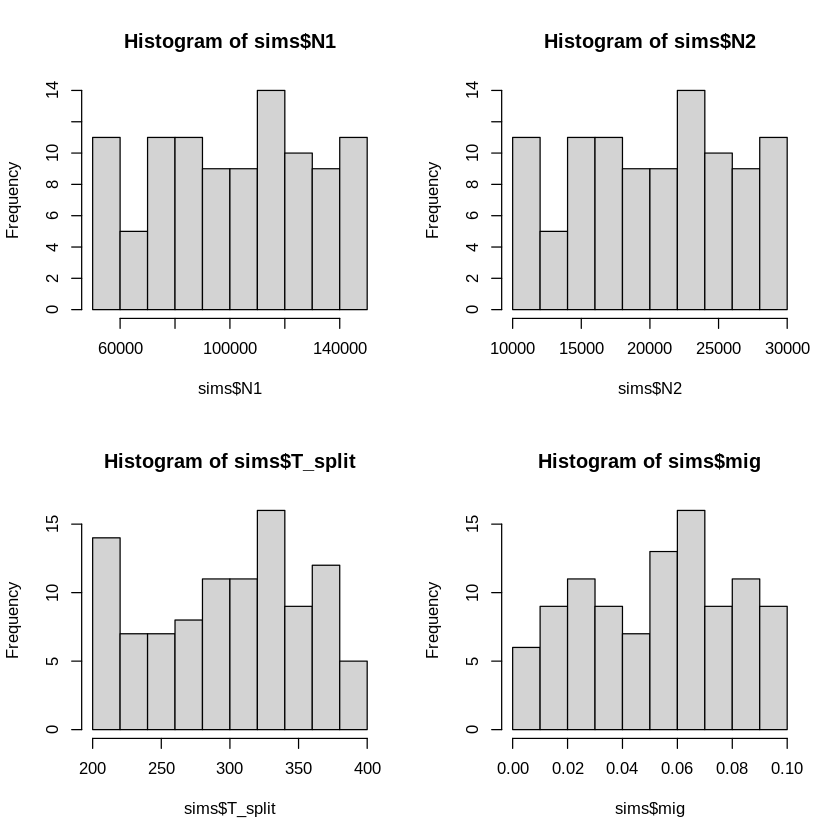

In [2]:
sims <- read.csv("mosquito-task1.csv", head=T)

# check prior distributions
par(mfrow=c(2,2))
hist(sims$N1)
hist(sims$N2)
hist(sims$T_split)
hist(sims$mig)


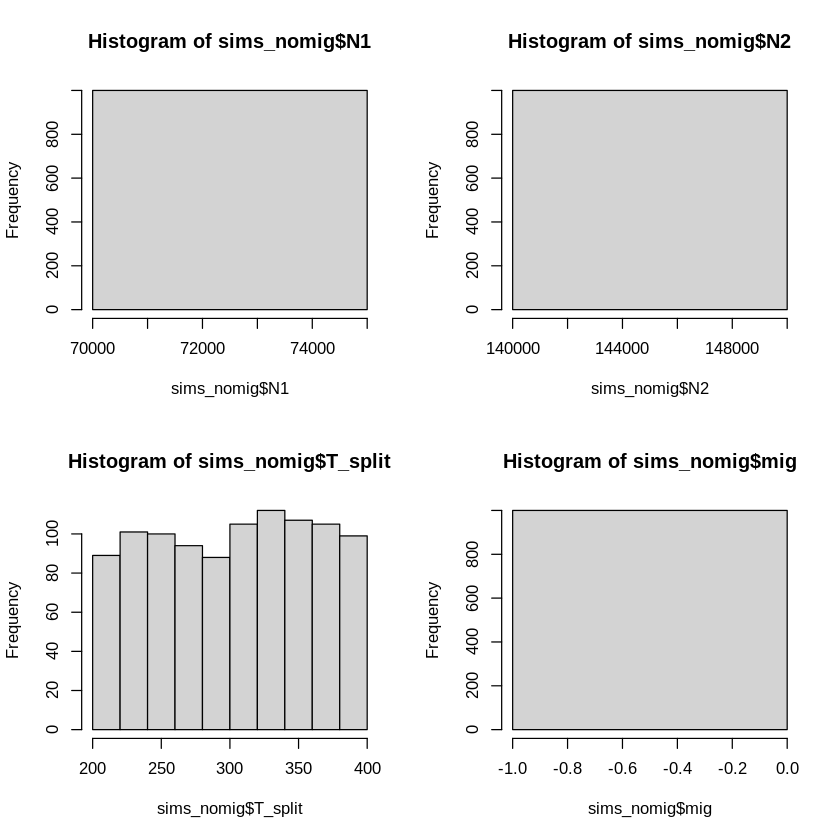

In [3]:
sims_nomig <- read.csv("mosquito-task2_no_mig.csv", head=T)

# check prior distributions
par(mfrow=c(2,2))
hist(sims_nomig$N1)
hist(sims_nomig$N2)
hist(sims_nomig$T_split)
hist(sims_nomig$mig)


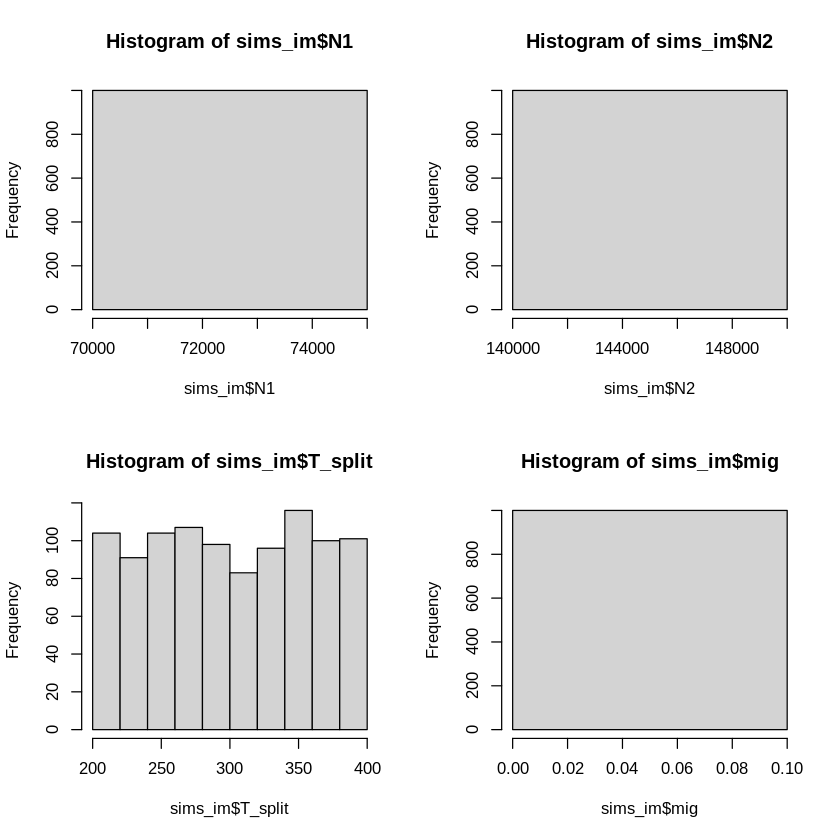

In [4]:
sims_im <- read.csv("mosquito-task2_im.csv", head=T)

# check prior distributions
par(mfrow=c(2,2))
hist(sims_im$N1)
hist(sims_im$N2)
hist(sims_im$T_split)
hist(sims_im$mig)

## Task 2: perform ABC model selection

In [5]:
# load observed summary stats
obs <- read.csv("mosquito-observed.csv", head=T)

# merge obs with retained sims to scale them
sumstats_modsel <- scale(rbind(obs,sims_nomig[5:12],sims_im[5:12]))
head(sumstats_modsel)

Fst,dxy,segsites1,segsites2,pi1,pi2,tajima1,tajima2
-1.2052669,-20.6028554,-6.9188169,5.5433544,-20.5107669,-20.6090423,-25.4790833,-26.01909998
1.4685236,0.7124645,0.8113965,1.0661694,0.7199551,0.6146988,0.1822599,-0.09908627
0.8252678,1.0099521,0.4824106,0.1230807,0.8433062,1.1240187,0.6100245,1.14801475
0.1259147,0.8856733,0.3139057,0.4302990,0.9204877,0.8404560,0.8482998,0.60767599
0.7827532,0.7465499,0.3139057,1.0304463,0.6809698,0.7630208,0.5585053,0.08734007
1.4689223,-1.9823241,-1.5476728,-1.1558048,-1.8943598,-2.1455897,-1.0188774,-1.56956539


In [6]:
# load ABC library
install.packages("abc")
library(abc)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘SparseM’, ‘MatrixModels’, ‘abc.data’, ‘quantreg’, ‘locfit’


Loading required package: abc.data

Loading required package: nnet

Loading required package: quantreg

Loading required package: SparseM

Loading required package: MASS

Loading required package: locfit

locfit 1.5-9.12 	 2025-03-05



In [8]:
# 1. Create an index vector
models <- c(rep("Isolation", 1000), rep("IM", 1000))

# 2. Run the model selection
mod_sel <- postpr(target = sumstats_modsel[1,],
                  index = models,
                  sumstat = sumstats_modsel[-1,],
                  tol = 0.05,
                  method = "rejection")

# 3. View the results
summary(mod_sel)

Call: 
postpr(target = sumstats_modsel[1, ], index = models, sumstat = sumstats_modsel[-1, 
    ], tol = 0.05, method = "rejection")
Data:
 postpr.out$values (100 posterior samples)
Models a priori:
 IM, Isolation
Models a posteriori:
 IM, Isolation

Proportion of accepted simulations (rejection):
       IM Isolation 
     0.68      0.32 

Bayes factors:
              IM Isolation
IM        1.0000    2.1250
Isolation 0.4706    1.0000




## Task 2: perform ABC parameter estimation

In [17]:
# find useful summary stats which correlate with T_split
cat("Fst: ", cor(sims_im$Fst, sims_im$T_split), "\n")
cat("dxy: ", cor(sims_im$dxy, sims_im$T_split), "\n")
cat("segsites1: ", cor(sims_im$segsites1, sims_im$T_split), "\n")
cat("segsites2: ", cor(sims_im$segsites2, sims_im$T_split), "\n")
cat("pi1: ", cor(sims_im$pi1, sims_im$T_split), "\n")
cat("pi2: ", cor(sims_im$pi2, sims_im$T_split), "\n")
cat("tajima1: ", cor(sims_im$tajima1, sims_im$T_split), "\n")
cat("tajima2: ", cor(sims_im$tajima2, sims_im$T_split), "\n")

Fst:  0.01089463 
dxy:  -0.009091879 
segsites1:  0.277357 
segsites2:  0.5390518 
pi1:  -0.007683793 
pi2:  -0.01078136 
tajima1:  -0.2989154 
tajima2:  -0.4944793 


In [19]:
# check if simulated retained summary stats contain the observed one
quantile(sims_im$Fst); cat(obs$Fst)
quantile(sims_im$segsites1); cat(obs$segsites1)
quantile(sims_im$segsites2); cat(obs$segsites2)


0%           25%           50%           75%          100% 
-5.079051e-04 -1.108377e-04  3.433773e-07  1.009309e-04  4.746402e-04

-0.0001438266

0%        25%        50%        75%       100% 
0.03798000 0.04004500 0.04054667 0.04106667 0.04260000

0.03447079

0%        25%        50%        75%       100% 
0.04584000 0.04767333 0.04829000 0.04890667 0.05103333

0.05331101

In [20]:
# merge obs with retained sims to scale them
sumstats <- scale(rbind(obs[c(1,3,4)],sims_im[,c(5,7,8)]))
head(sumstats)

Fst,segsites1,segsites2
-0.9265891,-7.7412523,5.40692712
0.1508432,0.3838356,0.54343671
-0.1805935,0.2139224,0.83093993
-0.8643125,0.9360534,-0.02438214
-0.3691629,0.0694962,-0.95158001
-1.2778538,-1.2133483,-0.13219584


In [21]:
est <- abc(target=sumstats[1,], param=sims_im$T_split, sumstat=sumstats[-1,], tol=0.05, method="rejection")

Warning message in abc(target = sumstats[1, ], param = sims_im$T_split, sumstat = sumstats[-1, :
“No parameter names are given, using P1, P2, ...”


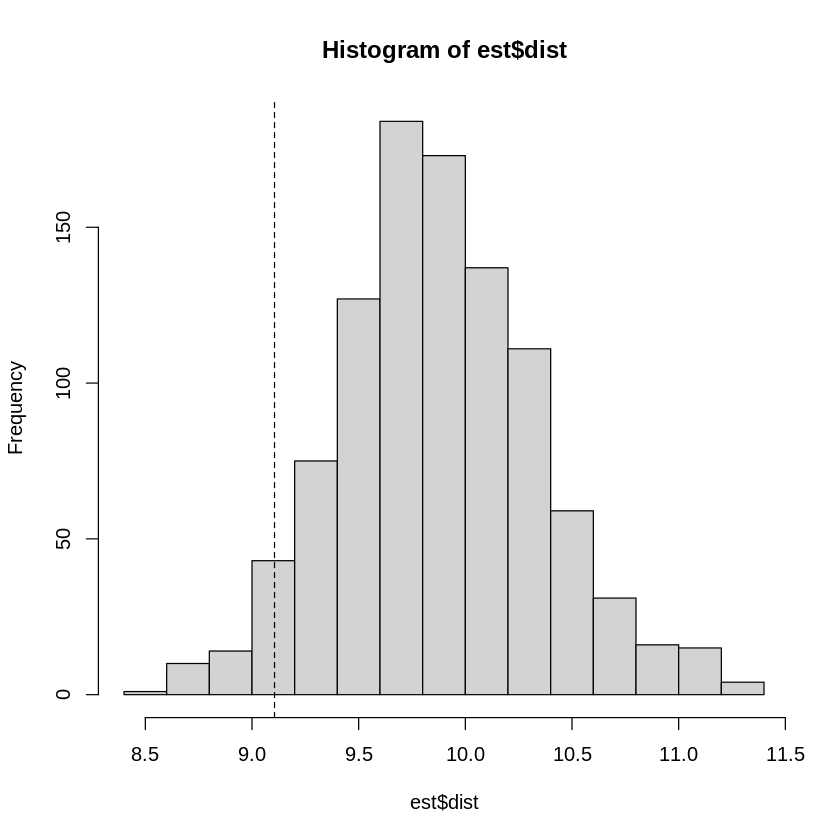

In [22]:
# check distances in the acceptance region
hist(est$dist)
abline(v=max(est$dist[which(est$region)]), lty=2)

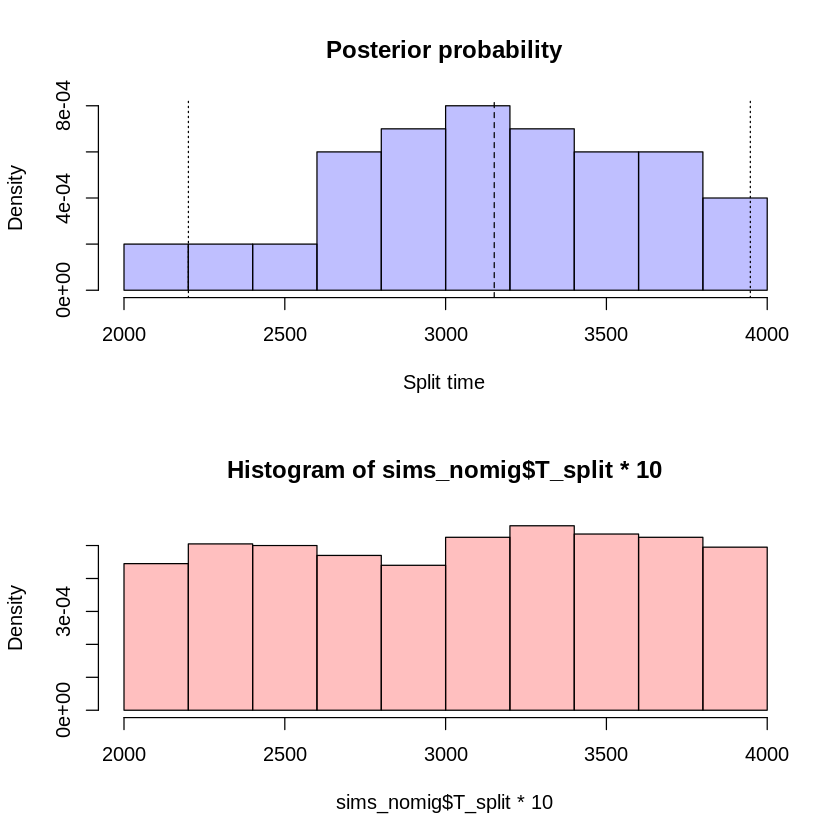

In [14]:
# posterior distribution
par(mfrow=c(2,1))
hist(est$unadj.values * 10, freq=FALSE, xlim=range(sims_nomig$T_split * 10), col=rgb(0,0,1,1/4), main="Posterior probability", xlab="Split time")

# MAP
map <- mean(est$unadj.values * 10)
abline(v=map, lty=2)

# confidence intervals
hpd <- quantile(x=est$unadj.values * 10, probs=c(0.025,0.975))
abline(v=hpd, lty=3)

# prior
hist(sims_nomig$T_split * 10, freq=FALSE, xlim=range(sims_nomig$T_split * 10), col=rgb(1,0,0,1/4))


## Task 3: Evaluate the performance with cross-validation

Confusion matrix based on 100 samples for each model.

$tol0.05
          IM Isolation
IM        97         3
Isolation  6        94


Mean model posterior probabilities (rejection)

$tol0.05
              IM Isolation
IM        0.8735    0.1265
Isolation 0.1355    0.8645



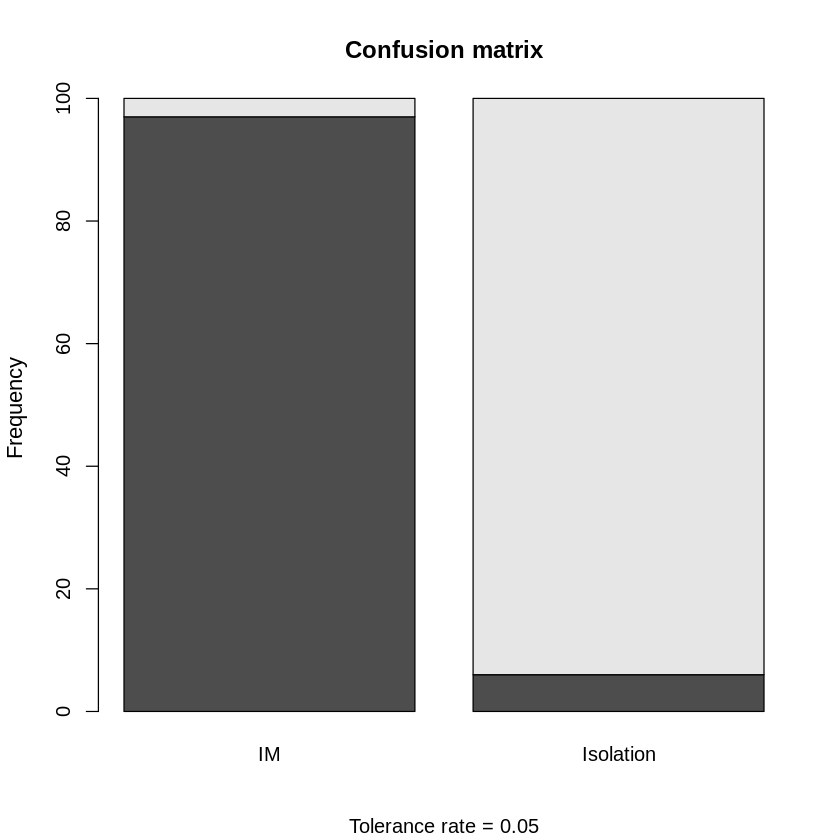

In [15]:
# Cross-validation for model selection
# nval = number of cross-validation points (e.g., 100)
cv_model <- cv4postpr(index = models,
                      sumstat = sumstats_modsel[-1,],
                      nval = 100,
                      tol = 0.05,
                      method = "rejection")

# 1. View the Confusion Matrix
summary(cv_model)

# 2. Visualize it
plot(cv_model)

Prediction error based on a cross-validation sample of 100



           P1
0.05 1.094518

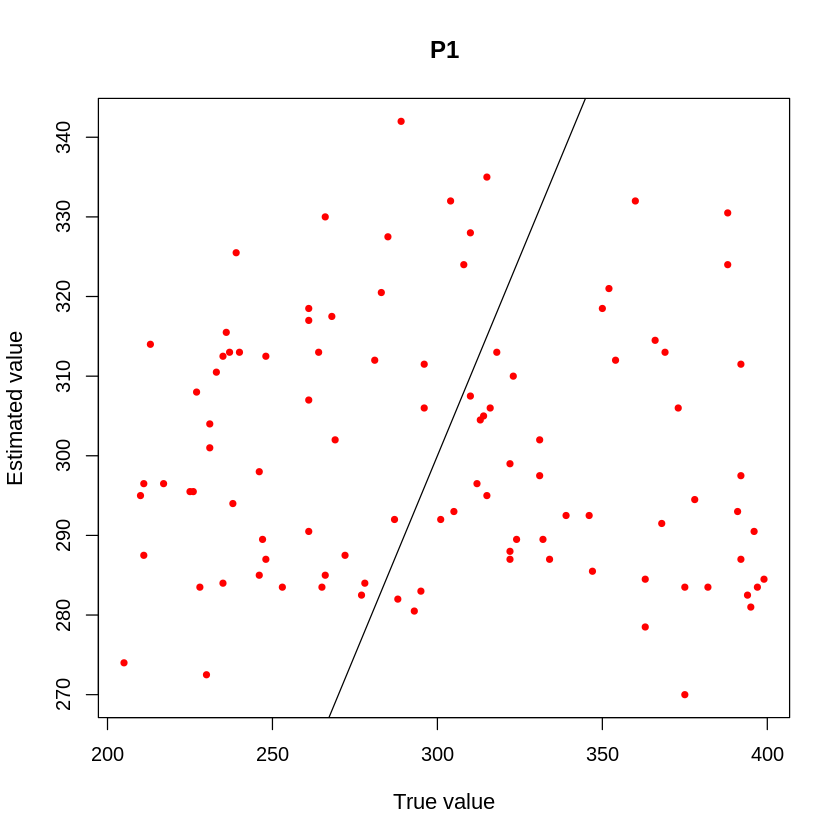

In [16]:
# Cross-validation for parameter estimation
cv_param <- cv4abc(param = sims_im$T_split,
                   sumstat = sumstats[-1,],
                   nval = 100,
                   tol = 0.05,
                   method = "rejection")

# This shows the "Prediction Error"
# A value near 0 means high precision; near 1 means the ABC is no better than guessing.
summary(cv_param)
plot(cv_param)